<a href="https://colab.research.google.com/github/DOHA-BASEM3/FINAL-PROJECT/blob/main/Oraib_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

6. Deep Learning with TensorFlow and Keras

6.1 Load Preprocessed Data

In [2]:
# Connect Google Drive to access the preprocessed files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Load the preprocessed features and labels
import numpy as np

X_scaled = np.load('/content/drive/MyDrive/ML_Final_Project/X_scaled.npy')
y        = np.load('/content/drive/MyDrive/ML_Final_Project/y.npy')

print(f'✅ Data loaded!')
print(f'X_scaled shape : {X_scaled.shape}')
print(f'y shape        : {y.shape}')

✅ Data loaded!
X_scaled shape : (283726, 30)
y shape        : (283726,)


In [8]:
# Verify data dimensions and inspect the class distribution
print("X_scaled shape:", X_scaled.shape)
print("y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)

print("Class distribution:")
for label, count in zip(unique, counts):
    print(label, ":", count)

X_scaled shape: (283726, 30)
y shape: (283726,)
Class distribution:
0 : 283253
1 : 473


6.2 Separate Normal and Fraud Transactions

In [9]:
# Separate normal and fraudulent transactions based on class labels

X_normal = X_scaled[y == 0]
X_fraud = X_scaled[y == 1]

print("Normal transactions shape:", X_normal.shape)
print("Fraud transactions shape:", X_fraud.shape)

Normal transactions shape: (283253, 30)
Fraud transactions shape: (473, 30)


6.3 Prepare Training and Validation Data

In [10]:
# Split normal transactions into training and validation sets

from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)

Training data shape: (226602, 30)
Validation data shape: (56651, 30)


6.4 Build Autoencoder Architecture

In [11]:
# Build the Autoencoder architecture using TensorFlow and Keras

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

input_dim = X_train.shape[1]

# Input layer
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dropout(0.1)(encoded)
latent_space = Dense(8, activation="relu", name="latent_space")(encoded)

# Decoder
decoded = Dense(16, activation="relu")(latent_space)
output_layer = Dense(input_dim, activation="linear")(decoded)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Compile model
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

6.5 Train the Autoencoder Model

In [12]:
# Train the Autoencoder model using normal transactions

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7743 - val_loss: 0.5037
Epoch 2/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5152 - val_loss: 0.4268
Epoch 3/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4706 - val_loss: 0.3925
Epoch 4/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4472 - val_loss: 0.3727
Epoch 5/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4359 - val_loss: 0.3607
Epoch 6/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4287 - val_loss: 0.3537
Epoch 7/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4228 - val_loss: 0.3507
Epoch 8/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4163 - val_loss: 0.3468
Epoch 9/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4100 - val_loss: 0.3381
Epoch 10/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4056 - val_loss: 0.3335
Epoch 11/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4041 - val_loss: 0.3293
Epoch 12/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

6.6 Loss Curves

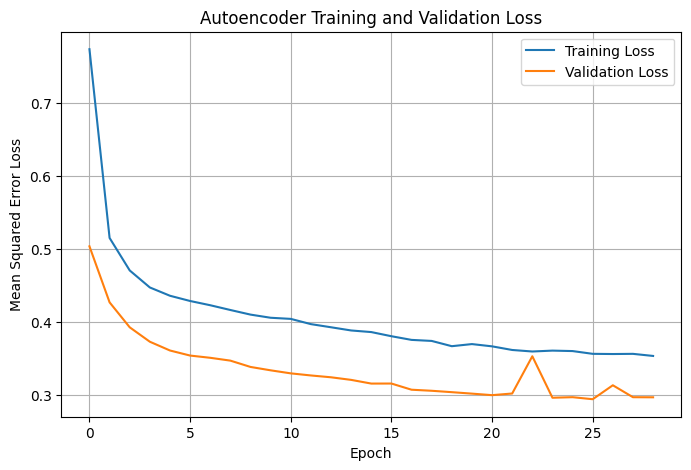

In [14]:
# Visualize the training and validation loss of the Autoencoder

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.title("Autoencoder Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

6.7 Reconstruction Error and Thresholding

In [15]:
# Prepare the test set for anomaly detection

X_test = np.concatenate([X_val, X_fraud], axis=0)

y_test = np.concatenate([
    np.zeros(len(X_val)),
    np.ones(len(X_fraud))
], axis=0)

print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

unique_test, counts_test = np.unique(y_test, return_counts=True)

print("Test class distribution:")
for label, count in zip(unique_test, counts_test):
    print(label, ":", count)

Test data shape: (57124, 30)
Test labels shape: (57124,)
Test class distribution:
0.0 : 56651
1.0 : 473


In [16]:
# Calculate the reconstruction error for each transaction

X_test_pred = autoencoder.predict(X_test)

reconstruction_error = np.mean(
    np.square(X_test - X_test_pred),
    axis=1
)

print("Reconstruction error shape:", reconstruction_error.shape)
print("Minimum error:", reconstruction_error.min())
print("Maximum error:", reconstruction_error.max())
print("Mean error:", reconstruction_error.mean())

1786/1786 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step
Reconstruction error shape: (57124,)
Minimum error: 0.014200522417679946
Maximum error: 90.38386603308274
Mean error: 0.4308947465662057


In [17]:
# Select a threshold and classify transactions as normal or anomalous

threshold = np.percentile(reconstruction_error, 99)

print("Selected threshold:", threshold)

y_pred = (reconstruction_error > threshold).astype(int)

print("Predicted class distribution:")
unique_pred, counts_pred = np.unique(y_pred, return_counts=True)

for label, count in zip(unique_pred, counts_pred):
    print(label, ":", count)

Selected threshold: 2.9447444885153873
Predicted class distribution:
0 : 56552
1 : 572


6.8 Model Evaluation

In [19]:
# Evaluate the Autoencoder anomaly detection performance

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, reconstruction_error)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Confusion Matrix:
[[56437   214]
 [  115   358]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56651
         1.0       0.63      0.76      0.69       473

    accuracy                           0.99     57124
   macro avg       0.81      0.88      0.84     57124
weighted avg       0.99      0.99      0.99     57124

Accuracy: 0.9942405993978013
Precision: 0.6258741258741258
Recall: 0.7568710359408034
F1-score: 0.6851674641148325
ROC-AUC: 0.9461723337539074


6.9 Accuracy and Performance Summary

In [20]:
# Accuracy and Performance Summary

print("Autoencoder Performance Summary")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

Autoencoder Performance Summary
Accuracy : 0.9942405993978013
Precision: 0.6258741258741258
Recall   : 0.7568710359408034
F1-score : 0.6851674641148325
ROC-AUC  : 0.9461723337539074


6.10 Reconstruction Error Visualization

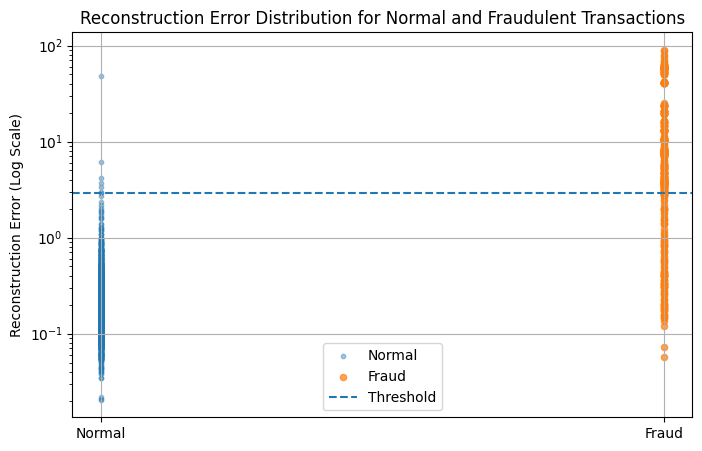

In [22]:
# Visualize reconstruction errors for normal and fraudulent transactions

import numpy as np
import matplotlib.pyplot as plt

normal_errors = reconstruction_error[y_test == 0]
fraud_errors = reconstruction_error[y_test == 1]

# Take a sample from normal transactions so the plot is readable
np.random.seed(42)
normal_sample_size = min(2000, len(normal_errors))
normal_sample = np.random.choice(
    normal_errors,
    size=normal_sample_size,
    replace=False
)

# Create x-axis positions
x_normal = np.zeros(len(normal_sample))
x_fraud = np.ones(len(fraud_errors))

plt.figure(figsize=(8, 5))

plt.scatter(
    x_normal,
    normal_sample,
    alpha=0.4,
    s=10,
    label="Normal"
)

plt.scatter(
    x_fraud,
    fraud_errors,
    alpha=0.7,
    s=20,
    label="Fraud"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Threshold"
)

plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yscale("log")
plt.ylabel("Reconstruction Error (Log Scale)")
plt.title("Reconstruction Error Distribution for Normal and Fraudulent Transactions")
plt.legend()
plt.grid(True)
plt.show()

6.11 Learned Latent Representations

1786/1786 ━━━━━━━━━━━━━━━━━━━━ 2s 855us/step
Latent representation shape: (57124, 8)


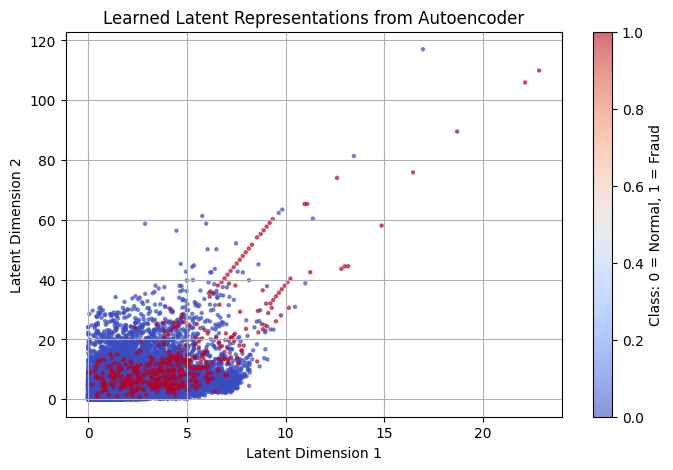

In [23]:
# Extract and visualize the learned latent representations from the Autoencoder

from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent_space").output
)

X_test_latent = encoder.predict(X_test)

print("Latent representation shape:", X_test_latent.shape)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_latent[:, 0],
    X_test_latent[:, 1],
    c=y_test,
    s=5,
    alpha=0.6,
    cmap="coolwarm"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Learned Latent Representations from Autoencoder")
plt.colorbar(label="Class: 0 = Normal, 1 = Fraud")
plt.grid(True)
plt.show()